In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import seaborn as sns
import os

from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.formula.api as smf

# PNAS-ready style matching analysis/final_code/sample.py
_C_BLUE = "#1F77B4"      # baseline / current method
_C_ORANGE = "#D85A30"    # proposed method
_C_EVENT = "#D62728"
_C_ZERO = "#666666"
_C_LIGHT = "#BBBBBB"
_C_PURPLE = "#534AB7"
_C_AMBER = "#F4B445"
_MUTED_PALETTE = [_C_BLUE, _C_ORANGE, "#6AAA96", _C_AMBER, _C_PURPLE]

_FONT_TITLE = 11
_FONT_LABEL = 10
_FONT_TICK = 9
_FONT_LEGEND = 9
_FONT_ANNOT = 8


def apply_pnas_style():
    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "-",
        "grid.linewidth": 0.5,
        "axes.titlesize": _FONT_TITLE,
        "axes.titleweight": "normal",
        "axes.labelsize": _FONT_LABEL,
        "xtick.labelsize": _FONT_TICK,
        "ytick.labelsize": _FONT_TICK,
        "legend.fontsize": _FONT_LEGEND,
        "legend.frameon": False,
        "figure.dpi": 200,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })


def _setup_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(labelsize=_FONT_TICK, length=3, width=0.8)
    ax.grid(True, linewidth=0.5, alpha=0.25, color=_C_LIGHT)
    ax.set_axisbelow(True)


def _finalize(fig, ax_or_axes, xlabel=None, ylabel=None, title=None, save_path=None):
    axes = np.ravel(ax_or_axes).tolist() if hasattr(ax_or_axes, "__iter__") else [ax_or_axes]
    for ax in axes:
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=_FONT_LABEL)
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=_FONT_LABEL)
    if title is not None:
        if len(axes) == 1:
            axes[0].set_title(title, loc="left", fontsize=_FONT_TITLE, pad=10)
        else:
            fig.suptitle(title, fontsize=_FONT_TITLE + 1, y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


apply_pnas_style()

In [2]:
os.getcwd()

'/accounts/projects/jchayes/commnotes/analysis/two_stage'

In [3]:
from src.data_loader import *
from src.analysis import *
from src.visualization import *
from src.utils import *

import matrix_factorization, constants as c
import utility as utility

apply_pnas_style()

In [4]:
# --- Configuration (Corrected Paths) ---
# Using the absolute paths from your working environment
NOTES_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/notes-00000.tsv"
HISTORY_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/noteStatusHistory-00000.tsv"
RATINGS_DIR = "/scratch/users/commnotes/communitynotes/sourcecode/ratings"
PAPER_DATA_URL = "https://raw.githubusercontent.com/trenault/CommunityNotes/main/database_replication.csv"
WEEKLY_OUTPUTS_PATH = "/scratch/users/commnotes/communitynotes2022/communitynotes/static/sourcecode/weekly_outputs"

WEEKLY_OUTPUTS_PATH_2025 = "/scratch/users/commnotes/communitynotes/sourcecode/weekly_outputs"


max_date = "2024-06-01"

In [5]:
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2023-01-01",end_date_str=max_date)

# Convert helpfulnessLevel to numeric helpfulNum
ratings_df['helpfulNum'] = None
ratings_df.loc[ratings_df['helpfulnessLevel'] == 'HELPFUL', 'helpfulNum'] = 1.0
ratings_df.loc[ratings_df['helpfulnessLevel'] == 'SOMEWHAT_HELPFUL', 'helpfulNum'] = 0.5
ratings_df.loc[ratings_df['helpfulnessLevel'] == 'NOT_HELPFUL', 'helpfulNum'] = 0.0

# Drop rows where helpfulNum is NaN (ratings with no helpfulness level)
ratings_df = ratings_df[ratings_df['helpfulNum'].notna()]
ratings_df['helpfulNum'] = ratings_df['helpfulNum'].astype(float)

# Modify date variables in the ratings_df
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms').dt.normalize()
ratings_df['createdAtWeek'] = ratings_df['createdAtDate'] - pd.to_timedelta(ratings_df['createdAtDate'].dt.dayofweek, unit='d')
ratings_df.sort_values(by = 'createdAtWeek').head()

Found 16 total rating files. Processing them in chunks to filter by date.


Reading ratings: 100%|██████████| 16/16 [00:41<00:00,  2.60s/it]


,noteId,raterParticipantId,createdAtMillis,helpfulnessLevel,helpfulNum,createdAtDate,createdAtWeek
2004493,1609588529339719682,4901CE97A65AD7391D270D03FCF15E7A1CA15674EA5FF5...,1672611688878,HELPFUL,1.0,2023-01-01,2022-12-26
1824970,1593413691357151232,F1F60C21C682EC3DCFE732F204AEFD887032ECF6EB8171...,1672587480718,HELPFUL,1.0,2023-01-01,2022-12-26
2516078,1608913172332781569,967783331FB283498D7947EFBA239A9F665E09D07112B3...,1672577948573,NOT_HELPFUL,0.0,2023-01-01,2022-12-26
1833323,1609608048464785409,04B13DEFF47EAB4B0F78DA94A4847A3DD3796718AEA325...,1672616502739,HELPFUL,1.0,2023-01-01,2022-12-26
2291364,1609005923556790272,D70522F7B58C017847D5EA2D1B0BEA8A1E6F7E157C9C5F...,1672579136553,HELPFUL,1.0,2023-01-01,2022-12-26


In [6]:
# Read files as CSV
note_params_stage1 = pd.read_csv('output_final/note_params_weekly_stage1_20251112_174832.csv')
rater_params_stage1 = pd.read_csv('output_final/rater_params_weekly_stage1_20251112_174832.csv')
note_params_stage2 = pd.read_csv('output_final/note_params_weekly_stage2_20251112_174832.csv')
rater_params_stage2 = pd.read_csv('output_final/rater_params_weekly_stage2_20251112_174832.csv')

global_bias_stage1 = pd.read_csv('output_final/global_bias_weekly_stage1_20251112_174832.csv')
global_bias_stage2 = pd.read_csv('output_final/global_bias_weekly_stage2_20251112_174832.csv')

In [7]:
def merge_factors(ratings_df, note_df, rater_df):
    """
    Merge the most recent note and rater parameters for each rating using merge_asof.
    Uses factors from weeks strictly before the rating week (direction='backward', allowing exact matches excluded).
    
    Parameters:
    -----------
    ratings_df : pd.DataFrame
        DataFrame with ratings, must have 'createdAtWeek', 'noteId', 'raterParticipantId'
    note_df : pd.DataFrame
        DataFrame with note parameters by week, must have 'createdAtWeek', 'noteId'
    rater_df : pd.DataFrame
        DataFrame with rater parameters by week, must have 'createdAtWeek', 'raterParticipantId'
    
    Returns:
    --------
    pd.DataFrame
        ratings_df with merged note and rater factors
    """
    # Ensure createdAtWeek is datetime
    ratings_df = ratings_df.copy()
    ratings_df['createdAtWeek'] = pd.to_datetime(ratings_df['createdAtWeek'])
    note_df = note_df.copy()
    note_df['createdAtWeek'] = pd.to_datetime(note_df['createdAtWeek'])
    rater_df = rater_df.copy()
    rater_df['createdAtWeek'] = pd.to_datetime(rater_df['createdAtWeek'])
    
    # Ensure consistent dtypes for merge keys (convert to str to avoid string[python] vs object issues)
    ratings_df['noteId'] = ratings_df['noteId'].astype(str)
    ratings_df['raterParticipantId'] = ratings_df['raterParticipantId'].astype(str)
    note_df['noteId'] = note_df['noteId'].astype(str)
    rater_df['raterParticipantId'] = rater_df['raterParticipantId'].astype(str)
    
    # Sort all dataframes by date (required for merge_asof)
    ratings_df = ratings_df.sort_values('createdAtWeek')
    note_df = note_df.sort_values('createdAtWeek')
    rater_df = rater_df.sort_values('createdAtWeek')
    
    # Merge note parameters - use direction='backward' with allow_exact_matches=False
    result = pd.merge_asof(
        ratings_df,
        note_df,
        on='createdAtWeek',
        by='noteId',
        direction='backward',
        allow_exact_matches=False,  # This excludes the current week
        suffixes=('', '_note')
    )
    
    # Merge rater parameters - use direction='backward' with allow_exact_matches=False
    result = pd.merge_asof(
        result,
        rater_df,
        on='createdAtWeek',
        by='raterParticipantId',
        direction='backward',
        allow_exact_matches=False,  # This excludes the current week
        suffixes=('', '_rater')
    )
    
    return result

In [8]:
merged_df1 = merge_factors(ratings_df, note_params_stage1, rater_params_stage1)
merged_df2 = merge_factors(ratings_df, note_params_stage2, rater_params_stage2)

In [9]:
merged_df1 = merged_df1.dropna()
merged_df2 = merged_df2.dropna()

In [10]:
# Convert createdAtWeek to datetime for merging
global_bias_stage1['createdAtWeek'] = pd.to_datetime(global_bias_stage1['createdAtWeek'])
global_bias_stage2['createdAtWeek'] = pd.to_datetime(global_bias_stage2['createdAtWeek'])

merged_df1 = merged_df1.merge(global_bias_stage1, on='createdAtWeek', how='left')
merged_df2 = merged_df2.merge(global_bias_stage2, on='createdAtWeek', how='left')

In [11]:
merged_df1['helpfulEstimate'] = merged_df1['globalBias'] + merged_df1['raterIntercept'] + merged_df1['noteIntercept'] + merged_df1['raterFactor1'] * merged_df1['noteFactor1']
merged_df2['helpfulEstimate'] = merged_df2['globalBias'] + merged_df2['raterIntercept'] + merged_df2['noteIntercept'] + merged_df2['raterFactor1'] * merged_df2['noteFactor1']

In [12]:
merged_df1['abs_residual'] = np.abs(merged_df1['helpfulNum'] - merged_df1['helpfulEstimate'])
merged_df2['abs_residual'] = np.abs(merged_df2['helpfulNum'] - merged_df2['helpfulEstimate'])

In [13]:
display(np.mean(merged_df1['abs_residual']))
display(np.mean(merged_df2['abs_residual']))

np.float64(0.23610329897464555)

np.float64(0.2245892754058092)

In [ ]:
# Compute mean and standard error by week for both dataframes
weekly_stats1 = merged_df1.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats1['se'] = weekly_stats1['std'] / np.sqrt(weekly_stats1['count'])

weekly_stats2 = merged_df2.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats2['se'] = weekly_stats2['std'] / np.sqrt(weekly_stats2['count'])


def plot_abs_residual_comparison_pnas(
    weekly_stats1,
    weekly_stats2,
    metrics=(('mean', 'Mean absolute residual', '(a) Mean'), ('median', 'Median absolute residual', '(b) Median')),
    save_path='plots/weekly_abs_residuals.png',
    title='Out-of-sample residuals: matrix factorization vs. two-stage estimator',
):
    d1 = weekly_stats1.copy()
    d2 = weekly_stats2.copy()
    d1['createdAtWeek'] = pd.to_datetime(d1['createdAtWeek'])
    d2['createdAtWeek'] = pd.to_datetime(d2['createdAtWeek'])

    merged = d1.merge(
        d2,
        on='createdAtWeek',
        suffixes=('_mf', '_ts'),
    ).sort_values('createdAtWeek')
    merged['week_num'] = np.arange(len(merged))

    apply_pnas_style()
    fig, axes = plt.subplots(1, len(metrics), figsize=(11, 4.0), sharex=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, (metric, ylabel, panel_title) in zip(axes, metrics):
        x = merged['week_num'].to_numpy(dtype=float)
        y_mf = merged[f'{metric}_mf'].to_numpy(dtype=float)
        y_ts = merged[f'{metric}_ts'].to_numpy(dtype=float)

        ax.fill_between(x, y_mf, y_ts, where=(y_mf >= y_ts), color=_C_ORANGE, alpha=0.10, linewidth=0)
        ax.scatter(x, y_mf, s=10, color=_C_BLUE, alpha=0.35, linewidths=0, zorder=2)
        ax.scatter(x, y_ts, s=10, color=_C_ORANGE, alpha=0.35, linewidths=0, zorder=2)

        if len(x) >= 4:
            sm_mf = lowess(y_mf, x, frac=0.25, return_sorted=True)
            sm_ts = lowess(y_ts, x, frac=0.25, return_sorted=True)
            ax.plot(sm_mf[:, 0], sm_mf[:, 1], color=_C_BLUE, lw=2.2, label='Matrix factorization (current)')
            ax.plot(sm_ts[:, 0], sm_ts[:, 1], color=_C_ORANGE, lw=2.2, label='Two-stage weighted (proposed)')
        else:
            ax.plot(x, y_mf, color=_C_BLUE, lw=2.2, label='Matrix factorization (current)')
            ax.plot(x, y_ts, color=_C_ORANGE, lw=2.2, label='Two-stage weighted (proposed)')

        improvement = np.nanmean((y_mf - y_ts) / y_mf) * 100
        ax.text(
            0.97,
            0.03,
            f'Avg. reduction: {improvement:.1f}%',
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=_FONT_LEGEND,
            color=_C_ORANGE,
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=_C_ORANGE, lw=0.5, alpha=0.85),
        )

        tick_idx = np.linspace(0, len(merged) - 1, min(5, len(merged)), dtype=int)
        tick_labels = merged.iloc[tick_idx]['createdAtWeek'].dt.strftime('%Y-%m-%d')
        ax.set_xticks(tick_idx)
        ax.set_xticklabels(tick_labels, rotation=35, ha='right')
        ax.set_xlabel('Week')
        ax.set_ylabel(ylabel)
        ax.set_title(panel_title, loc='left', pad=8)
        _setup_ax(ax)

    axes[0].legend(loc='upper right', frameon=False, fontsize=_FONT_LEGEND)
    _finalize(fig, axes, title=title, save_path=save_path)
    return merged


weekly_residual_comparison = plot_abs_residual_comparison_pnas(
    weekly_stats1,
    weekly_stats2,
    save_path='plots/weekly_abs_residuals.png',
)

In [15]:
np.mean((weekly_stats1['mean'] - weekly_stats2['mean'])/weekly_stats1['mean'])

np.float64(0.05730556859610952)

In [16]:
np.std((weekly_stats1['mean'] - weekly_stats2['mean'])/weekly_stats1['mean'])

np.float64(0.04754061609472877)

In [17]:
np.mean((weekly_stats1['median'] - weekly_stats2['median'])/weekly_stats1['median'])

np.float64(0.27996875189758086)

In [18]:
np.std((weekly_stats1['median'] - weekly_stats2['median'])/weekly_stats1['median'])

np.float64(0.06781215010618492)

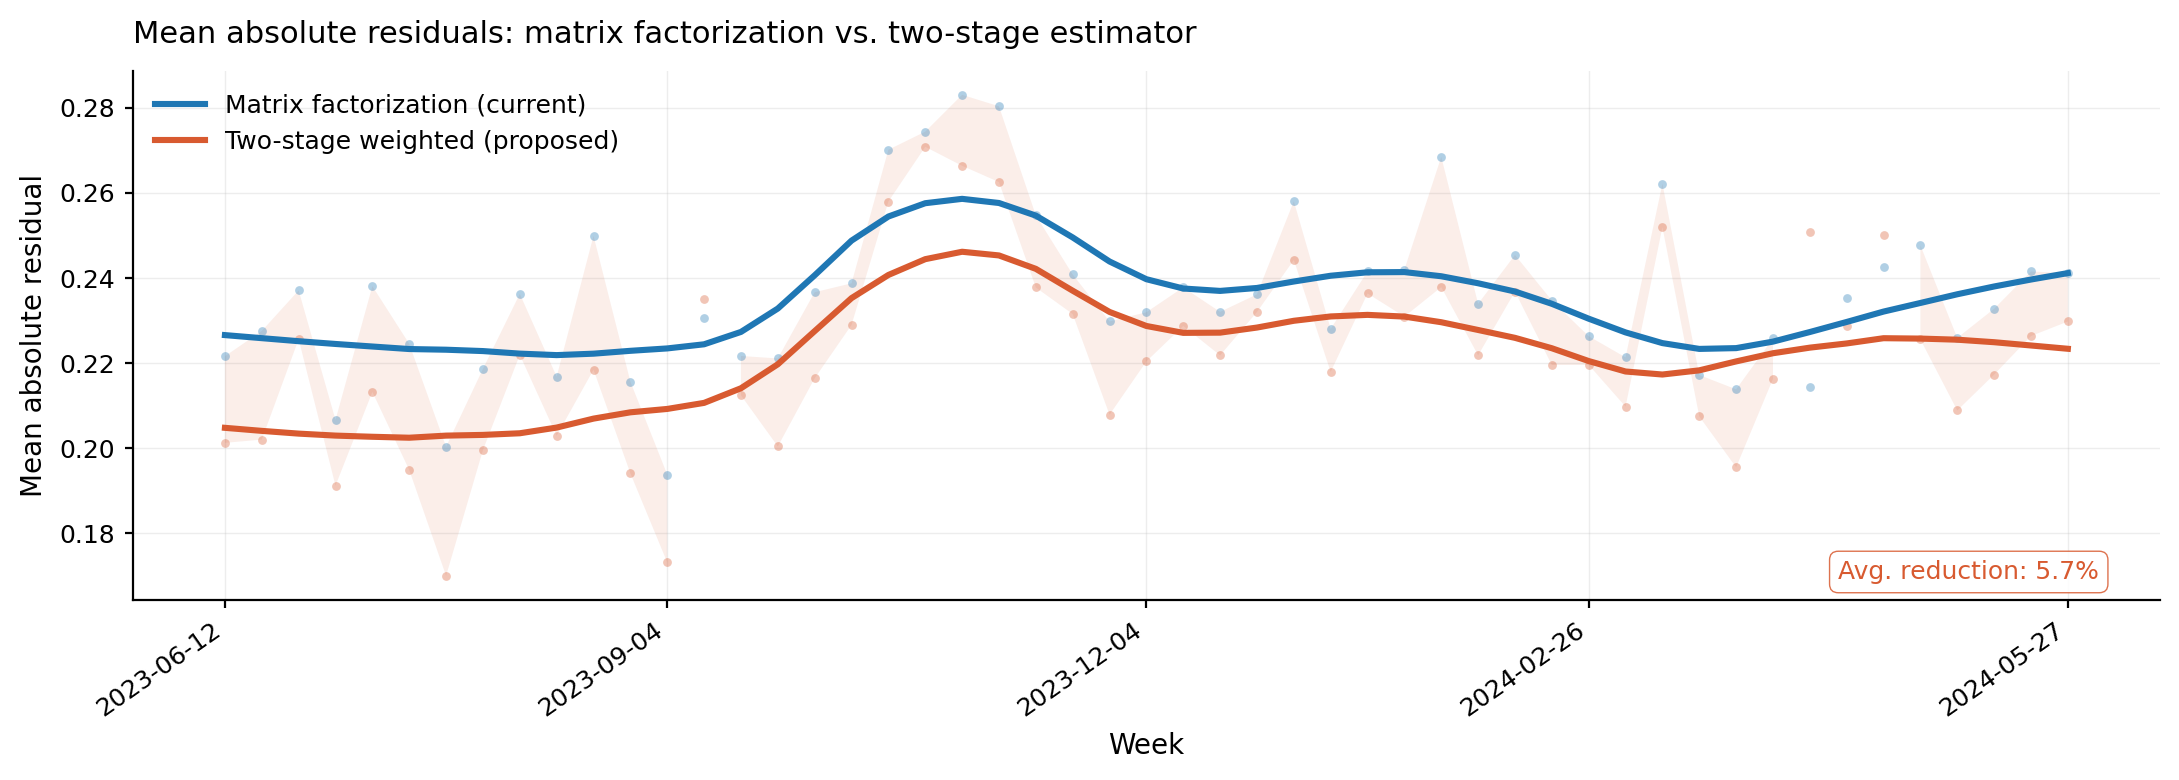

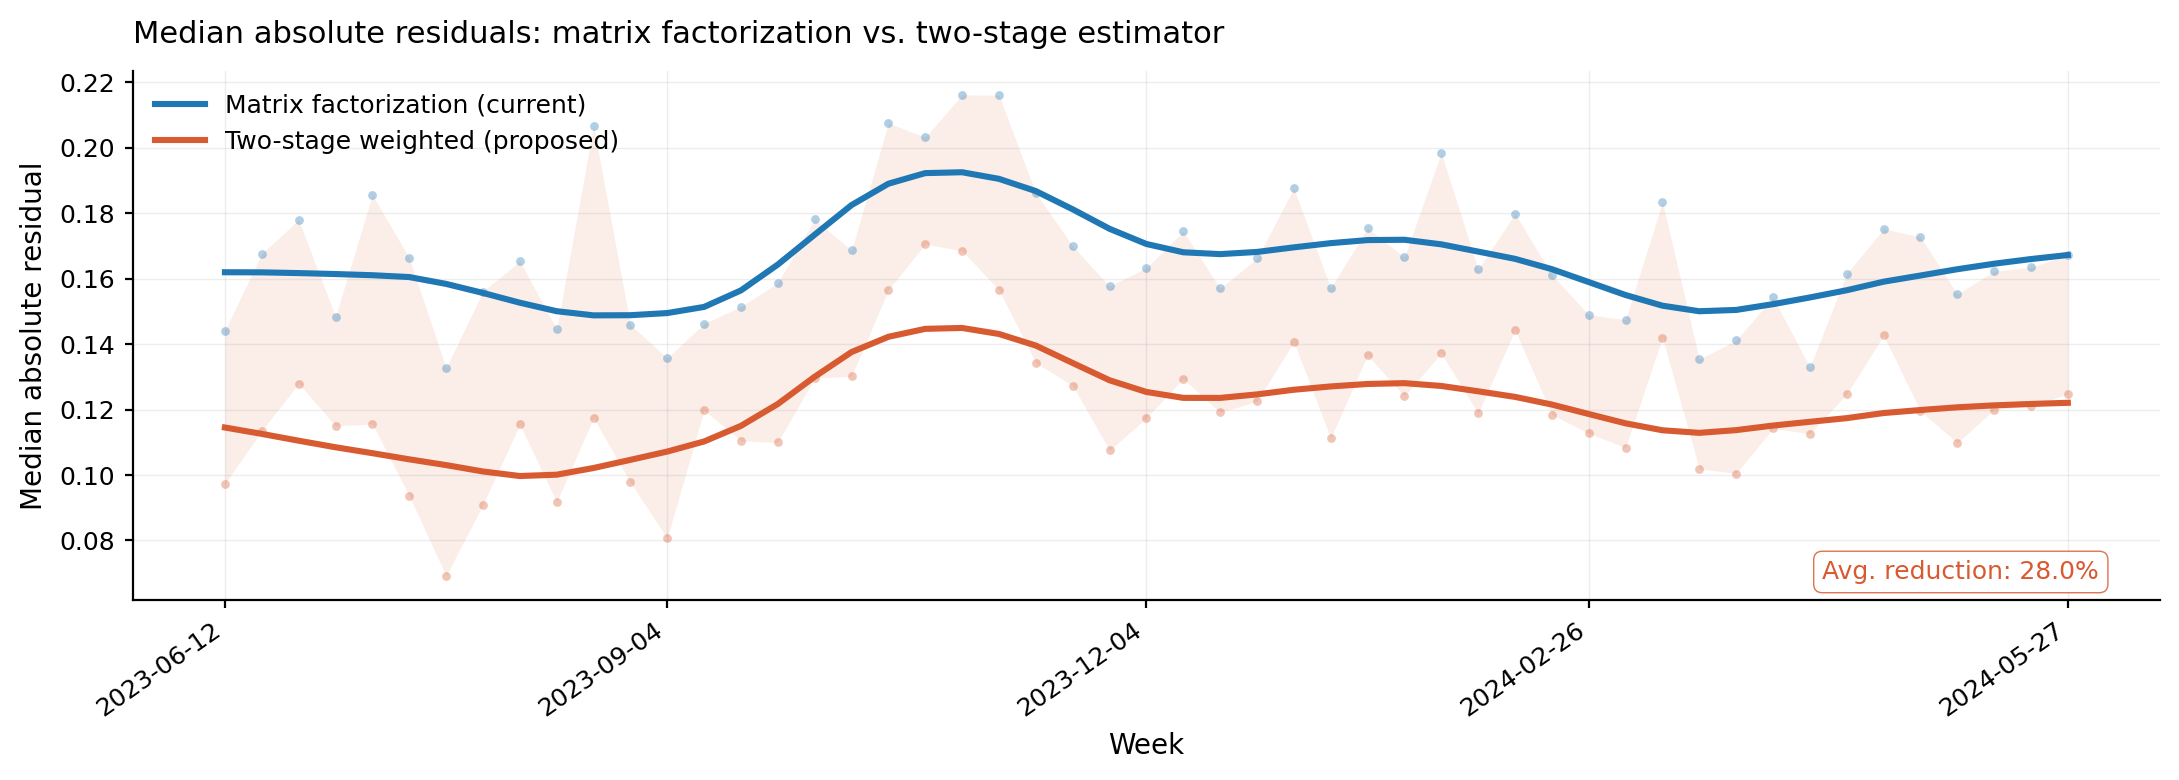

,createdAtWeek,mean_mf,median_mf,std_mf,count_mf,se_mf,mean_ts,median_ts,std_ts,count_ts,se_ts,week_num
0,2023-06-12,0.221629,0.144135,0.219418,1178,0.006393,0.201284,0.097303,0.235598,1178,0.006864,0
1,2023-06-19,0.227571,0.167630,0.199873,1036,0.006210,0.202043,0.113531,0.220221,1036,0.006842,1
2,2023-06-26,0.237094,0.177915,0.211604,1249,0.005987,0.225642,0.127957,0.255966,1249,0.007243,2
3,2023-07-03,0.206664,0.148399,0.198911,1271,0.005579,0.191220,0.115007,0.212019,1271,0.005947,3
4,2023-07-10,0.238088,0.185554,0.206151,935,0.006742,0.213248,0.115601,0.243191,935,0.007953,4
5,2023-07-17,0.224546,0.166378,0.198100,1020,0.006203,0.194911,0.093646,0.321037,1020,0.010052,5
6,2023-07-24,0.200354,0.132684,0.194422,1524,0.004980,0.170043,0.069213,0.241015,1524,0.006174,6
7,2023-07-31,0.218648,0.156056,0.198625,1491,0.005144,0.199586,0.090948,0.253264,1491,0.006559,7
8,2023-08-07,0.236274,0.165316,0.220905,1907,0.005059,0.221957,0.115437,0.269319,1907,0.006167,8
9,2023-08-14,0.216829,0.144578,0.209663,1504,0.005406,0.202954,0.091754,0.267184,1504,0.006889,9


In [19]:
# Compute mean and standard error by week for both dataframes
weekly_stats1 = merged_df1.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats1['se'] = weekly_stats1['std'] / np.sqrt(weekly_stats1['count'])

weekly_stats2 = merged_df2.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats2['se'] = weekly_stats2['std'] / np.sqrt(weekly_stats2['count'])

plot_abs_residual_comparison_pnas(
    weekly_stats1,
    weekly_stats2,
    metrics=(('mean', 'Mean absolute residual', 'Mean'),),
    save_path='plots/weekly_abs_residuals_mean.png',
    title='Mean absolute residuals: matrix factorization vs. two-stage estimator',
)

plot_abs_residual_comparison_pnas(
    weekly_stats1,
    weekly_stats2,
    metrics=(('median', 'Median absolute residual', 'Median'),),
    save_path='plots/weekly_abs_residuals_median.png',
    title='Median absolute residuals: matrix factorization vs. two-stage estimator',
)